In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if os.path.exists('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')
    project_path = '/content/drive/MyDrive/mimic-sepsis-ews'
else:
    project_path = os.path.abspath(os.path.join(os.getcwd(), '..'))

processed_path = f'{project_path}/data/processed'
print(f"Environment: {'Colab' if 'drive' in project_path else 'Local VSCode'}")

df = pd.read_csv(f'{processed_path}/master_features.csv')
df['Sepsis'] = df['sepsis_label'].map({0: 'No Sepsis', 1: 'Sepsis'})
print(f"Dataset shape: {df.shape}")
print(f"Sepsis positive: {df['sepsis_label'].sum()} ({df['sepsis_label'].mean():.1%})")

Environment: Local VSCode
Dataset shape: (29405, 42)
Sepsis positive: 4391 (14.9%)


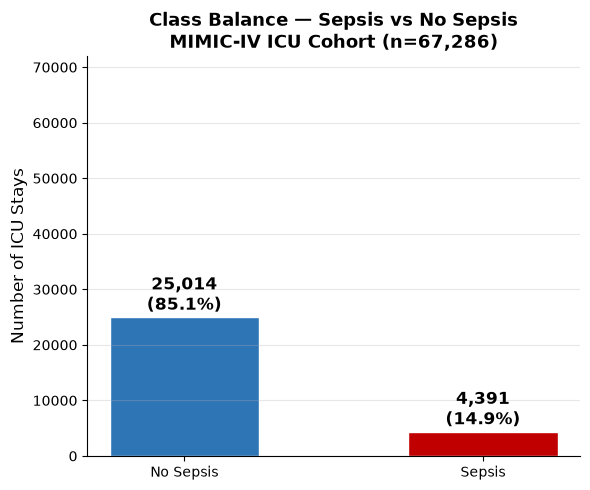

Saved


In [2]:
# Plot 1: Class Balance
fig, ax = plt.subplots(figsize=(6, 5))

counts = df['Sepsis'].value_counts()
colors = ['#2E75B6', '#C00000']
bars = ax.bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='white')

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{count:,}\n({count/len(df):.1%})',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Class Balance — Sepsis vs No Sepsis\nMIMIC-IV ICU Cohort (n=67,286)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of ICU Stays', fontsize=12)
ax.set_ylim(0, 72000)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{processed_path}/plot_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

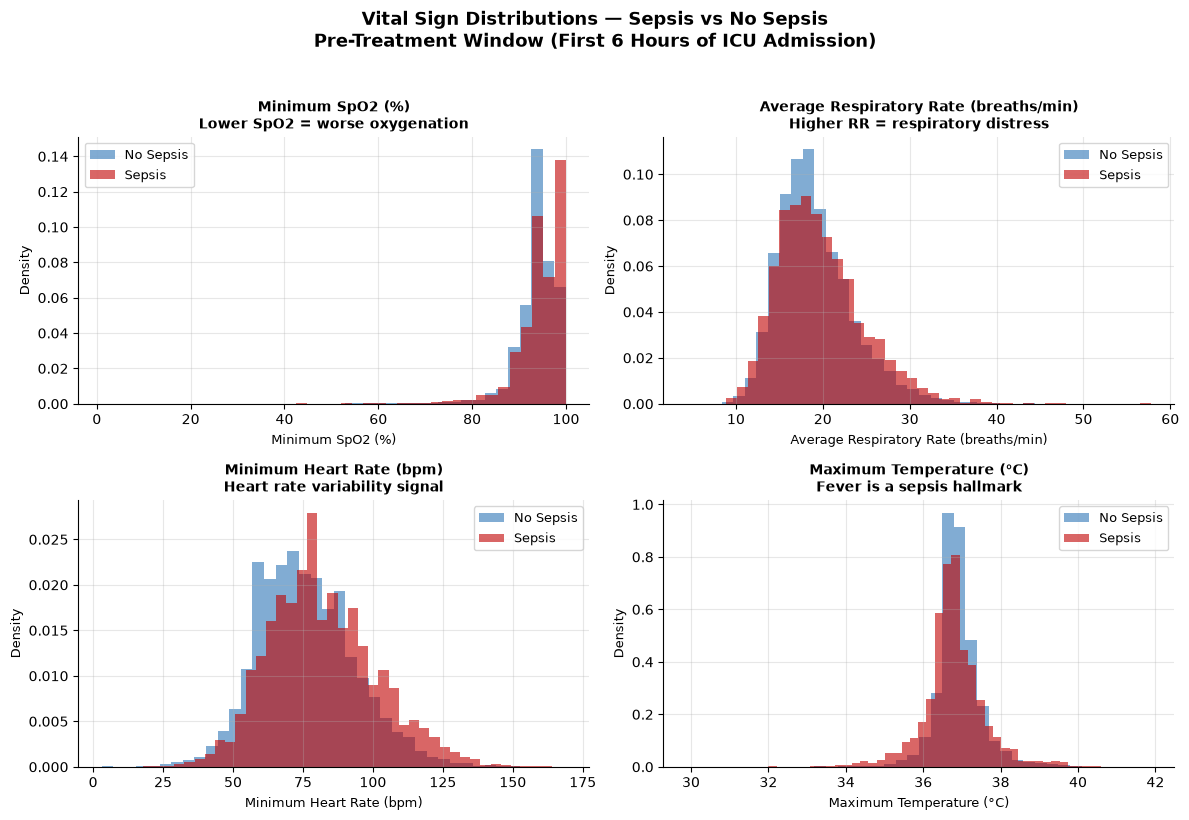

Saved


In [3]:
# Plot 2: Key Vital Sign Distributions by Sepsis Label
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

vitals = [
    ('min_spo2', 'Minimum SpO2 (%)', 'Lower SpO2 = worse oxygenation'),
    ('avg_rr', 'Average Respiratory Rate (breaths/min)', 'Higher RR = respiratory distress'),
    ('min_hr', 'Minimum Heart Rate (bpm)', 'Heart rate variability signal'),
    ('max_temp', 'Maximum Temperature (\u00b0C)', 'Fever is a sepsis hallmark'),
]

colors = {'No Sepsis': '#2E75B6', 'Sepsis': '#C00000'}

for ax, (col, label, subtitle) in zip(axes.flatten(), vitals):
    for group, color in colors.items():
        subset = df[df['Sepsis'] == group][col].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label=group, density=True, edgecolor='none')

    ax.set_title(f'{label}\n{subtitle}', fontsize=10, fontweight='bold')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Vital Sign Distributions — Sepsis vs No Sepsis\nPre-Treatment Window (First 6 Hours of ICU Admission)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{processed_path}/plot_vitals_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

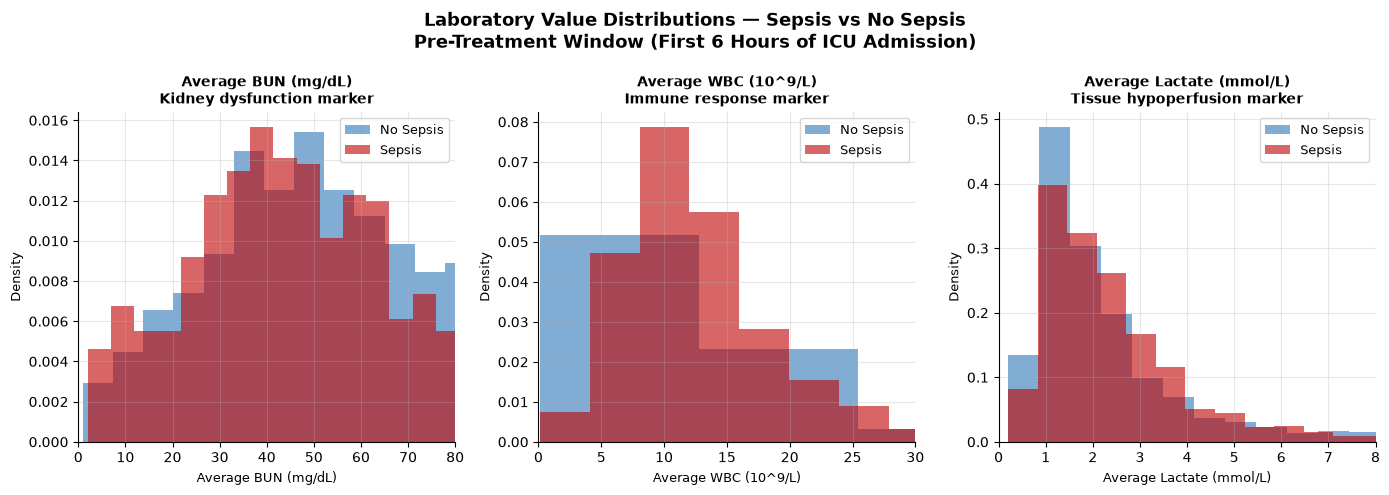

Saved


In [4]:
# Plot 3: Key Lab Distributions by Sepsis Label
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

labs = [
    ('avg_bun', 'Average BUN (mg/dL)', 'Kidney dysfunction marker', 0, 80),
    ('avg_wbc', 'Average WBC (10^9/L)', 'Immune response marker', 0, 30),
    ('avg_lactate', 'Average Lactate (mmol/L)', 'Tissue hypoperfusion marker', 0, 8),
]

colors = {'No Sepsis': '#2E75B6', 'Sepsis': '#C00000'}

for ax, (col, label, subtitle, xmin, xmax) in zip(axes, labs):
    for group, color in colors.items():
        subset = df[df['Sepsis'] == group][col].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label=group, density=True, edgecolor='none')

    ax.set_title(f'{label}\n{subtitle}', fontsize=10, fontweight='bold')
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.set_xlim(xmin, xmax)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Laboratory Value Distributions — Sepsis vs No Sepsis\nPre-Treatment Window (First 6 Hours of ICU Admission)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{processed_path}/plot_labs_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

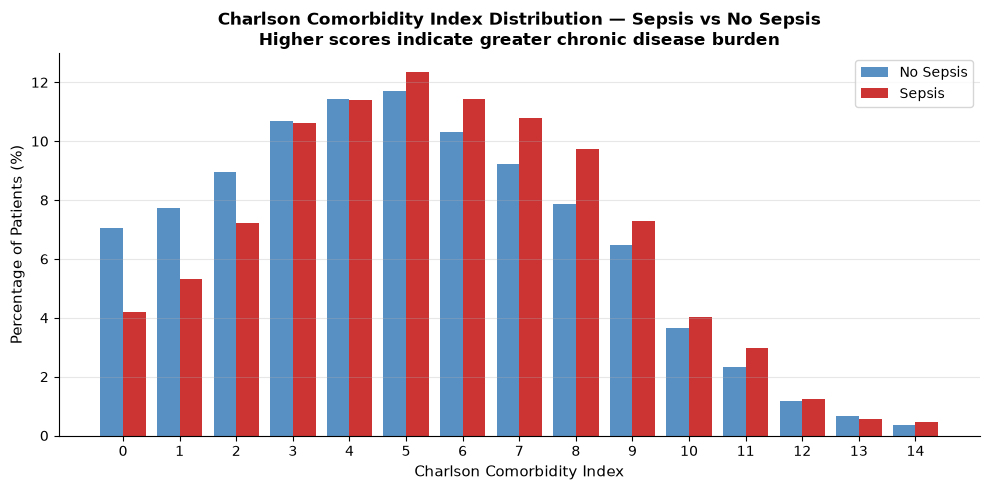

Saved


In [5]:
# Plot 4: Charlson Comorbidity Index by Sepsis Label
fig, ax = plt.subplots(figsize=(10, 5))

charlson_sepsis = df[df['Sepsis'] == 'Sepsis']['charlson_comorbidity_index'].value_counts().sort_index()
charlson_no_sepsis = df[df['Sepsis'] == 'No Sepsis']['charlson_comorbidity_index'].value_counts().sort_index()

# Normalize to percentage
charlson_sepsis = charlson_sepsis / charlson_sepsis.sum() * 100
charlson_no_sepsis = charlson_no_sepsis / charlson_no_sepsis.sum() * 100

x = range(0, 15)
width = 0.4

ax.bar([i - width/2 for i in x],
       [charlson_no_sepsis.get(i, 0) for i in x],
       width=width, color='#2E75B6', alpha=0.8, label='No Sepsis')
ax.bar([i + width/2 for i in x],
       [charlson_sepsis.get(i, 0) for i in x],
       width=width, color='#C00000', alpha=0.8, label='Sepsis')

ax.set_title('Charlson Comorbidity Index Distribution — Sepsis vs No Sepsis\nHigher scores indicate greater chronic disease burden',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Charlson Comorbidity Index', fontsize=11)
ax.set_ylabel('Percentage of Patients (%)', fontsize=11)
ax.set_xticks(list(x))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{processed_path}/plot_charlson.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

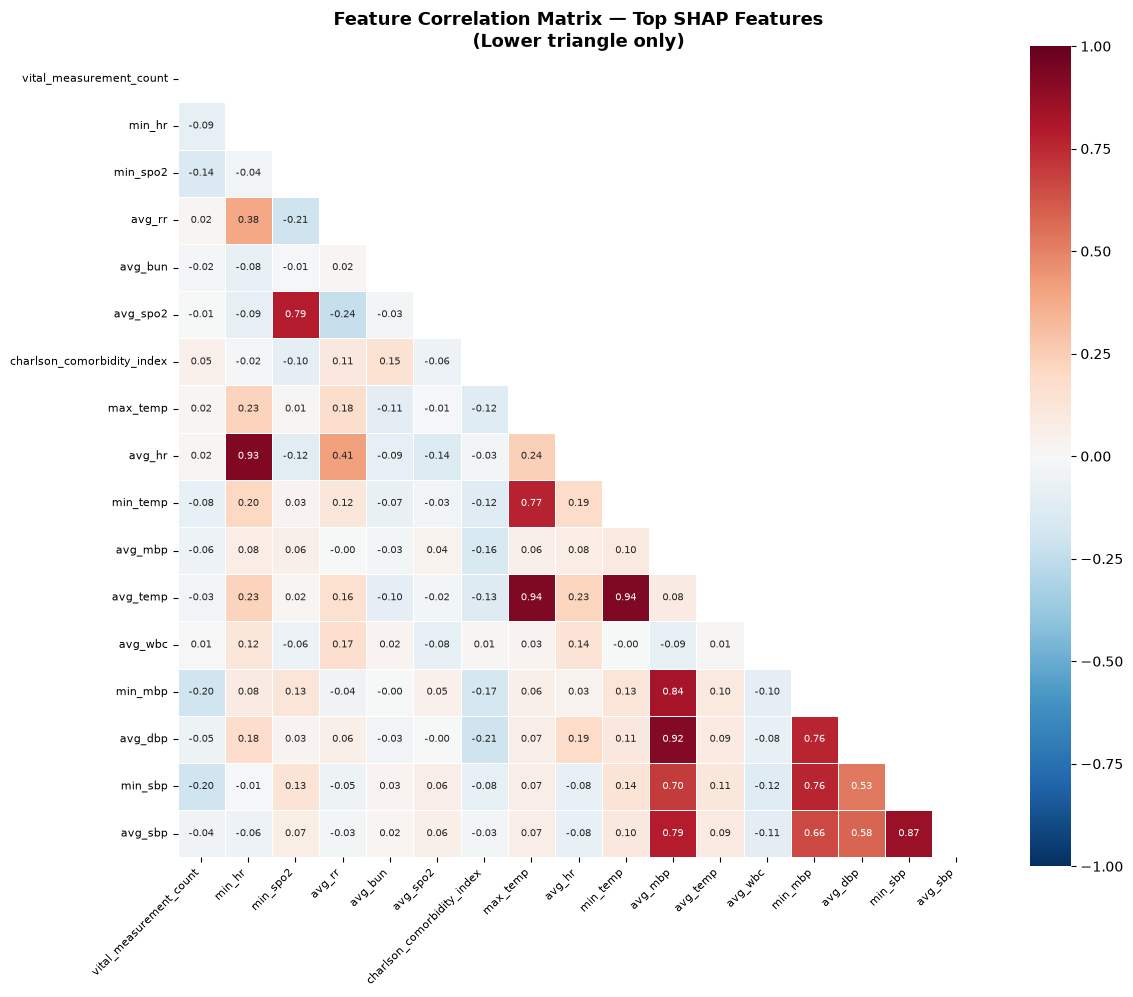

Saved


In [6]:
# Plot 5: Correlation heatmap of top SHAP features
top_features = [
    'vital_measurement_count', 'min_hr', 'min_spo2', 'avg_rr',
    'avg_bun', 'avg_spo2', 'charlson_comorbidity_index', 'max_temp',
    'avg_hr', 'min_temp', 'avg_mbp', 'avg_temp',
    'avg_wbc', 'min_mbp', 'avg_dbp', 'min_sbp', 'avg_sbp'
]

corr_matrix = df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)

ax.set_title('Feature Correlation Matrix — Top SHAP Features\n(Lower triangle only)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f'{processed_path}/plot_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

In [7]:
# Summary of all saved EDA outputs
import os

eda_files = [
    'plot_class_balance.png',
    'plot_vitals_distribution.png',
    'plot_labs_distribution.png',
    'plot_charlson.png',
    'plot_correlation.png'
]

print("EDA outputs saved to Google Drive:")
for f in eda_files:
    path = f'{processed_path}/{f}'
    size = os.path.getsize(path) / 1024
    print(f"  {f} ({size:.0f} KB)")

print(f"\nNotebook 02 complete.")
print(f"Total cohort: 67,286 ICU stays")
print(f"Sepsis positive: 7,594 (11.3%)")
print(f"Key finding: Sepsis patients show measurable physiological")
print(f"differences in vitals and labs BEFORE treatment initiation,")
print(f"validating the pre-treatment modeling approach.")

EDA outputs saved to Google Drive:
  plot_class_balance.png (38 KB)
  plot_vitals_distribution.png (132 KB)
  plot_labs_distribution.png (98 KB)
  plot_charlson.png (44 KB)
  plot_correlation.png (176 KB)

Notebook 02 complete.
Total cohort: 67,286 ICU stays
Sepsis positive: 7,594 (11.3%)
Key finding: Sepsis patients show measurable physiological
differences in vitals and labs BEFORE treatment initiation,
validating the pre-treatment modeling approach.
